In [1]:
""" 
PROGRAM :  diagnostics_basics.ipynb 

reads in intpp assimilation runs, historical simulations 
and raw forecasts under CMIP6 emissions 
to produce some basic diagnostics

STATUS  : Complete 
COMMENTS: (1) No adjusted forecast shown her
"""

' \nPROGRAM :  diagnostics_basics.ipynb \n\nreads in intpp assimilation runs, historical simulations \nand raw forecasts under CMIP6 emissions \nto produce some basic diagnostics\n\nSTATUS  : Complete \nCOMMENTS: (1) No adjusted forecast shown her\n'

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

from fnmatch import fnmatch
import pandas as pd
import configs
from prepare import (prepare_data_for_analysis, 
                    load_ONI,
                     calculate_climatology, 
                     calculate_detrended,
                     spco2_decomposition,
                     get_enso_events,
                     experiment_finder,
                     take_area_average)

from modules.plotting.module_plot_lines import *
from modules.analysis.module_data_load import load_biomes
from modules.data_info.module_data_info import biomes_module


In [3]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx
ENSO = configs.ENSO

### Configs

In [4]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'
biomes_directory =  "/space/hall7/sitestore/eccc/crd/cccma/users/rsa001/big_store/AI/FGCO2/data/biomes" 

assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = [ 'spco2', 'chlos', 'thetao'] #,'talk','dissic', 'no3',  'silicate', 'po4']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']
obs_source = {'spco2' : 'SOMFFN',
              'chlos' : 'ESACCI',
              'thetao' : 'SODA'} 

biomes_to_show = ['NEP']
 ## this could be a dictionary for each variable as they might have different sources.
decompose_spco2: bool = False
vars_to_det: list[str] =  None #['spco2']

### Data Loading

In [5]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            verbose = True)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/observation/SOMFFN
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/observation/ESACCI
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/thetao/observation/SODA

model directories: 

spco2 assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/assimilation/CanESM5-CanOE_1
spco2 historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/spco2/historical/CanESM5-CanOE
chlos assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/assimilation/CanESM5-CanOE_1
chlos historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/chlos/historical/CanESM5
/space/hall7/sitestore/eccc/crd

In [ ]:
bms_info = biomes_module(biomes_directory)
bms_dict = bms_info.data_dict['biomes']
bms_dir  = bms_dict['dir']
bms_file = bms_dict['file']
bms_dict_plot = bms_info.dict_biomes_plot
nbms = 17
bms_labels = [bms_info.biomes_dict[ii]['label'] for ii in np.arange(nbms)+1]

biomes = load_biomes(f'{bms_dir}',
                     f'{bms_file}') * mask_ocean_surface


mask_biomes = {}
for bms_label in bms_labels:
    bm = (biomes.MeanBiomes * mask_ocean_surface.squeeze()).where(biomes.MeanBiomes * mask_ocean_surface.squeeze() == bms_labels.index(bms_label)+1, 0)
    mask_biomes[bms_label] = bm.where(bm == 0,1) +  (biomes.MeanBiomes * mask_ocean_surface.squeeze()).where(np.isnan((biomes.MeanBiomes *mask_ocean_surface.squeeze())),0)

mask_biomes["global"] = mask_ocean_surface.where(mask_ocean_surface == 1)

loading global ocean biomes..
done


In [7]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [8]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_em_data:
        for exp in dict_em_data[var]:
            print(f'{var} {exp}')
            display(dict_em_data[var][exp].data)




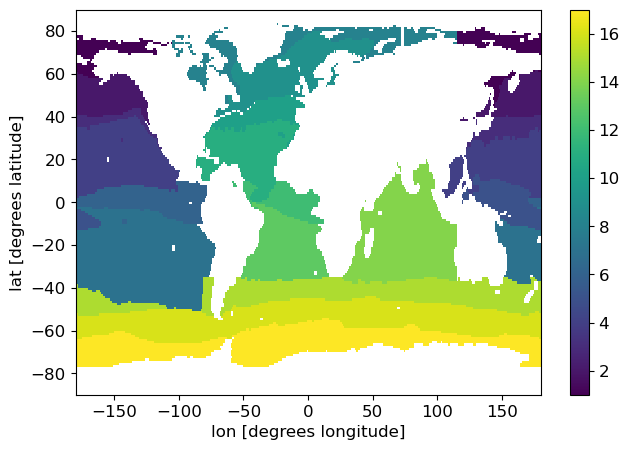

In [9]:
idisplay=True

if idisplay:
    (biomes.MeanBiomes * mask_ocean_surface ).where(biomes.MeanBiomes * mask_ocean_surface > 0).plot()


### Data Prep

In [10]:
if decompose_spco2:
    dict_em_data = spco2_decomposition(dict_em_data)

In [11]:
dict_em_clim = calculate_climatology(dict_em_data,
                                                   y0_base=None,
                                                   y1_base=None)

dict_em_clim =  take_area_average(dict_em_clim, mask_biomes) 


calculating spco2 CanESM5-CMOC_assimilation climatology over 1982 - 2022 ...


done.
calculating spco2 CanESM5-CanOE_1_assimilation climatology over 1982 - 2022 ...
done.
calculating spco2 CanESM5-CMOC_historical climatology over 1982 - 2022 ...
done.
calculating spco2 CanESM5-CanOE_historical climatology over 1982 - 2022 ...
done.
calculating spco2 obs climatology over 1982 - 2022 ...
done.
calculating chlos CanESM5-CMOC_assimilation climatology over 1982 - 2022 ...
done.
calculating chlos CanESM5-CanOE_1_assimilation climatology over 1982 - 2022 ...
done.
calculating chlos CanESM5-CMOC_historical climatology over 1982 - 2022 ...
done.
calculating chlos CanESM5-CanOE_historical climatology over 1982 - 2022 ...
done.
calculating chlos obs climatology over 1982 - 2022 ...
done.
calculating thetao CanESM5-CMOC_assimilation climatology over 1982 - 2022 ...
done.
calculating thetao CanESM5-CanOE_1_assimilation climatology over 1982 - 2022 ...
done.
calculating thetao CanESM5-CMOC_historical climatology over 1982 - 2022 ...
done.
calculating thetao CanESM5-CanOE_histo

### Plots

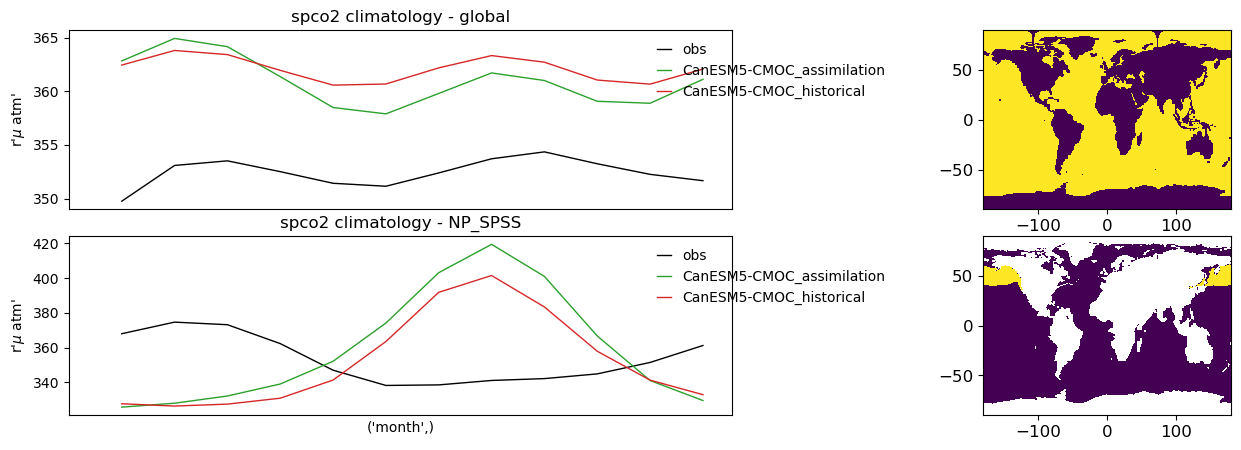

In [15]:
var = 'spco2'

model_experiment = ['observation', 'CanESM5 assimilation' , 'CanESM5 historical']

figsize = (15,5)


title = f'Anomalies {var}'
biomes_to_show = ["global", 'NP_SPSS']
show_trend = True
ylabel = units[var]
xlabel='month',

ds_dicts = dict_em_clim[var]
ds_list = experiment_finder(dict_em_data[var], model_experiment)



plot_ts_vs_lead_biomes(
            ds_list,
            ds_dicts,
            biomes_to_show,
            mask_biomes = mask_biomes,
            var_name=var,
            bbox= (.75,.5,.5,.5),
            figsize=figsize,
            ylabel = ylabel, 
            xlabel = xlabel)
